In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask_jobqueue/slurm.py:55: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/precippuzzle/lib/p

In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
#import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

## 1) Load data

_CTL_

In [4]:
# Define the path and file name pattern
data_path_pr_ctl = '/scratch/m/m300948/test_04/pr/'
data_path_prw_ctl = '/scratch/m/m300948/test_04/prw/'
data_path_hfls_ctl = '/scratch/m/m300948/test_04/hfls/'
#data_path_wa_ctl = '/scratch/m/m300948/test_04/3d/vertical_w/6hourly/'

#file_pattern = 'ctl_daily_{}_2020{:02d}*.nc'
file_pattern = 'ctl_daily_{}_2022*.nc'
#file_wa_pattern = 'ctl_daily_{}_plev_202{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# List of months
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Use glob to find all files matching the pattern for each month
pr_files = []
prw_files = []
hfls_files = []
#wa_files = []

for month in months:
    pr_files.extend(glob.glob(data_path_pr_ctl + file_pattern.format('pr', month)))
    prw_files.extend(glob.glob(data_path_prw_ctl + file_pattern.format('prw', month)))
    hfls_files.extend(glob.glob(data_path_hfls_ctl + file_pattern.format('hfls', month)))
#    wa_files.extend(glob.glob(data_path_wa_ctl + file_wa_pattern.format('wa', month)))

# Load datasets
pr_ctl = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
prw_ctl = xr.open_mfdataset(prw_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['prw']
hfls_ctl = xr.open_mfdataset(hfls_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['hfls']
#wa_ctl = xr.open_mfdataset(wa_files, chunks={'time': 1, 'plev':-1, 'lat': -1, 'lon': -1})['wa']

# Load the biome mask
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome_ctl = AMZ_BD.interp(latitude=pr_ctl.lat, longitude=pr_ctl.lon)
pr_ctl_mask = pr_ctl.where(ABinterp_biome_ctl == 0, np.nan)
prw_ctl_mask = prw_ctl.where(ABinterp_biome_ctl == 0, np.nan)
hfls_ctl_mask = hfls_ctl.where(ABinterp_biome_ctl == 0, np.nan)
#wa_ctl_mask = wa_ctl.where(ABinterp_biome_ctl == 0, np.nan)

# Select latitude and longitude range
pr_ctl_sel = pr_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) # kg m-2 s-1
prw_ctl_sel = prw_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) # kg m-2
hfls_ctl_sel = hfls_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) # W m-2
#wa_ctl_sel = wa_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)).sel(plev=50000) # m s-1

_DEF_

In [5]:
# Define the path and file name pattern
data_path_pr_def = '/scratch/m/m300948/def_100/pr/'
data_path_prw_def = '/scratch/m/m300948/def_100/prw/'
data_path_hfls_def = '/scratch/m/m300948/def_100/hfls/'
#data_path_wa_def = '/scratch/m/m300948/def_100/3d/vertical_w/6hourly/'

file_pattern = 'def_daily_{}_2022*.nc'
#file_pattern = 'def_daily_{}_2020{:02d}*.nc'
#file_wa_pattern = 'def_daily_{}_plev_202{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# List of months
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Use glob to find all files matching the pattern for each month
pr_files = []
prw_files = []
hfls_files = []
#wa_files = []

for month in months:
    pr_files.extend(glob.glob(data_path_pr_def + file_pattern.format('pr', month)))
    prw_files.extend(glob.glob(data_path_prw_def + file_pattern.format('prw', month)))
    hfls_files.extend(glob.glob(data_path_hfls_def + file_pattern.format('hfls', month)))
#    wa_files.extend(glob.glob(data_path_wa_def + file_wa_pattern.format('wa', month)))

# Load datasets
pr_def = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
prw_def = xr.open_mfdataset(prw_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['prw']
hfls_def = xr.open_mfdataset(hfls_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['hfls']
#wa_def = xr.open_mfdataset(wa_files, chunks={'time': 1, 'plev':-1, 'lat': -1, 'lon': -1})['wa']

# Load the biome mask
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome_def = AMZ_BD.interp(latitude=pr_def.lat, longitude=pr_def.lon)
pr_def_mask = pr_def.where(ABinterp_biome_def == 0, np.nan)
prw_def_mask = prw_def.where(ABinterp_biome_def == 0, np.nan)
hfls_def_mask = hfls_def.where(ABinterp_biome_def == 0, np.nan)
#wa_def_mask = wa_def.where(ABinterp_biome_def == 0, np.nan)

# Select latitude and longitude range
pr_def_sel = pr_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
prw_def_sel = prw_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
hfls_def_sel = hfls_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) 
#wa_def_sel = wa_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)).sel(plev=50000)

## 2) Calculate convergence

In [6]:
# masked - make the unit into mm/hour
pr_ctl_sel_mm_hour = (pr_ctl_sel).compute() * 3600 # mm/hr
prw_ctl_sel_mm_hour = (prw_ctl_sel).compute() # mm
ev_ctl_sel_mm_hour = (hfls_ctl_sel/28.94/24).compute() # mm/hr

In [7]:
# masked - make the unit into mm/hour
pr_def_sel_mm_hour = (pr_def_sel).compute() * 3600 # mm/hr
prw_def_sel_mm_hour = (prw_def_sel).compute()
ev_def_sel_mm_hour = (hfls_def_sel/28.94/24).compute()

_create the derivative of the prw_

In [8]:
ctl_time_diff = prw_ctl_sel_mm_hour['time'].diff('time') / np.timedelta64(1, 'h')
ctl_vapor_diff = prw_ctl_sel_mm_hour.diff('time')
ctl_prw_derivative = ctl_vapor_diff / ctl_time_diff
ctl_prw_derivative['time'] = prw_ctl_sel_mm_hour['time'][1:]

In [9]:
def_time_diff = prw_def_sel_mm_hour['time'].diff('time') / np.timedelta64(1, 'h')
def_vapor_diff = prw_def_sel_mm_hour.diff('time')
def_prw_derivative = def_vapor_diff / def_time_diff
def_prw_derivative['time'] = prw_def_sel_mm_hour['time'][1:]

### calculate convergence and separate its seasons

In [10]:
convg_ctl = pr_ctl_sel_mm_hour + ev_ctl_sel_mm_hour + ctl_prw_derivative
convg_def = pr_def_sel_mm_hour + ev_def_sel_mm_hour + def_prw_derivative

## 3) Select variables before the violent precipitation: PDF of convergence 1h prior to the intense pr

_CTL_

In [ ]:
# pr_ctl_sel_mm_hour
# ev_ctl_sel_mm_hour
# ctl_prw_derivative

In [11]:
# masked - make 6 hourly data to daily data
pr_ctl_sel_mm_hour_m = pr_ctl_sel_mm_hour.resample(time='H').mean()
pr_def_sel_mm_hour_m = pr_def_sel_mm_hour.resample(time='H').mean()

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(


In [12]:
convg_ctl_m = convg_ctl.resample(time='H').mean()
convg_def_m = convg_def.resample(time='H').mean()

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/groupby.py:668: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index_grouper = pd.Grouper(


In [12]:
convg_ctl_m.to_netcdf('/scratch/m/m300948/test_04/' + 'convg_ctl_m_2022.nc')
convg_def_m.to_netcdf('/scratch/m/m300948/def_100/' + 'convg_def_m_2022.nc')

In [13]:
import pandas as pd
# Mask one hour before the 6n+1-hourly data
ctl_mask = (pr_ctl_sel_mm_hour_m.time.dt.hour % 6 == 1) & (pr_ctl_sel_mm_hour_m > 50) # 6n+1 에 맞춰서 True false
pr_ctl_mask_sel = pr_ctl_sel_mm_hour_m.where(pr_ctl_sel_mm_hour_m['time'].dt.minute == 0, drop=True).where(ctl_mask) # Remove the minute dimension and apply mask (mm/hr)
# Extract only the desired hours (1, 7, 13, 19)
hours = pr_ctl_mask_sel['time'].dt.hour
desired_hours = [1, 7, 13, 19]
pr_ctl_mask_sel_6plus1 = pr_ctl_mask_sel.sel(time=hours.isin(desired_hours))

# Change the time index to 6-hourly, 00:00, 06:00, 12:00, 18:00
new_time = pd.date_range(start=pr_ctl_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1), 
                        periods=len(pr_ctl_mask_sel_6plus1.time), 
                        freq='6H')
# Assign the new time index to the dataset
pr_ctl_mask_sel_6plus1['time'] = new_time

# Same time
common_time = pr_ctl_mask_sel_6plus1.time.to_index().intersection(convg_ctl.time.to_index())
pr_ctl_sel_mm_hour_m_6plus1_common = pr_ctl_mask_sel_6plus1.sel(time=common_time)
convg_ctl_m_common = convg_ctl_m.sel(time=common_time)
#prw_ctl_sel_mm_hour_common = prw_ctl_sel_mm_hour.sel(time=common_time)
#ev_ctl_sel_mm_hour_common = ev_ctl_sel_mm_hour.sel(time=common_time)
#wa_ctl_sel_common = wa_ctl_sel.sel(time=common_time)

# Mask
mask = ~np.isnan(pr_ctl_sel_mm_hour_m_6plus1_common)
pr_ctl_sel_mm_hour_m_6plus1_common_mask = pr_ctl_sel_mm_hour_m_6plus1_common.where(mask)
convg_ctl_m_common_mask = convg_ctl_m_common.where(mask)
#prw_ctl_sel_mm_hour_common_mask = prw_ctl_sel_mm_hour_common.where(mask)
#ev_ctl_sel_mm_hour_common_mask = ev_ctl_sel_mm_hour_common.where(mask)
#wa_ctl_sel_common_mask = wa_ctl_sel_common.where(mask)

/tmp/ipykernel_3452079/335441466.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_time = pd.date_range(start=pr_ctl_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1),


In [13]:
pr_ctl_sel_mm_hour_m_6plus1_common_mask.to_netcdf('/scratch/m/m300948/test_04/' + 'pr_ctl_sel_mm_hour_m_6plus1_common_mask_2022.nc')

_DEF_

In [14]:
import pandas as pd
# Mask one hour before the 6n+1-hourly data
def_mask = (pr_def_sel_mm_hour_m.time.dt.hour % 6 == 1) & (pr_def_sel_mm_hour_m > 50) # 6n+1 에 맞춰서 True false
pr_def_mask_sel = pr_def_sel_mm_hour_m.where(pr_def_sel_mm_hour_m['time'].dt.minute == 0, drop=True).where(def_mask) # Remove the minute dimension and apply mask (mm/hr)
# Extract only the desired hours (1, 7, 13, 19)
hours = pr_def_mask_sel['time'].dt.hour
desired_hours = [1, 7, 13, 19]
pr_def_mask_sel_6plus1 = pr_def_mask_sel.sel(time=hours.isin(desired_hours))

# Change the time index to 6-hourly, 00:00, 06:00, 12:00, 18:00
new_time = pd.date_range(start=pr_def_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1), 
                        periods=len(pr_def_mask_sel_6plus1.time), 
                        freq='6H')
# Assign the new time index to the dataset
pr_def_mask_sel_6plus1['time'] = new_time

# Same time
common_time = pr_def_mask_sel_6plus1.time.to_index().intersection(convg_def.time.to_index())
pr_def_sel_mm_hour_m_6plus1_common = pr_def_mask_sel_6plus1.sel(time=common_time)
convg_def_m_common = convg_def_m.sel(time=common_time)
#prw_def_sel_mm_hour_common = prw_def_sel_mm_hour.sel(time=common_time)
#ev_def_sel_mm_hour_common = ev_def_sel_mm_hour.sel(time=common_time)
#wa_def_sel_common = wa_def_sel.sel(time=common_time)

# Mask
mask = ~np.isnan(pr_def_sel_mm_hour_m_6plus1_common)
pr_def_sel_mm_hour_m_6plus1_common_mask = pr_def_sel_mm_hour_m_6plus1_common.where(mask)
convg_def_m_common_mask = convg_def_m_common.where(mask)
#prw_def_sel_mm_hour_common_mask = prw_def_sel_mm_hour_common.where(mask)
#ev_def_sel_mm_hour_common_mask = ev_def_sel_mm_hour_common.where(mask)
#wa_def_sel_common_mask = wa_def_sel_common.where(mask)

/tmp/ipykernel_3452079/1134847118.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_time = pd.date_range(start=pr_def_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1),


In [15]:
pr_def_sel_mm_hour_m_6plus1_common_mask.to_netcdf('/scratch/m/m300948/def_100/' + 'pr_def_sel_mm_hour_m_6plus1_common_mask_2022.nc')

_Plot the PDF of convergence 1h prior to the intense precipitation events_

In [40]:
xarray_names = ['convg_ctl','convg_def']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [16]:
xarray_names = ['convg_ctl_m_common_mask','convg_def_m_common_mask']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [ ]:
print(convg_ctl_f)

In [21]:
convg_ctl_m_common_mask_f_2022 = convg_ctl_m_common_mask_f
convg_def_m_common_mask_f_2022 = convg_def_m_common_mask_f

In [22]:
np.save('/scratch/m/m300948/test_04/' + 'convg_ctl_m_common_mask_f_2022.npy', convg_ctl_m_common_mask_f_2022)
np.save('/scratch/m/m300948/def_100/' + 'convg_def_m_common_mask_f_2022.npy', convg_def_m_common_mask_f_2022)

# Reload the saved data

## PDF

In [5]:
# Load them back
file_pattern = "/scratch/m/m300948/test_04/convg_ctl_m_common_mask_f_*.npy"
file_list = sorted(glob.glob(file_pattern))
convg_f_ctl_arrays = [np.load(file) for file in file_list]

In [6]:
# Load them back
file_pattern = "/scratch/m/m300948/def_100/convg_def_m_common_mask_f_*.npy"
file_list = sorted(glob.glob(file_pattern))
convg_f_def_arrays = [np.load(file) for file in file_list]

In [7]:
convg_f_ctl_arrays[0]

array([ 5.51155011, 16.90978241, 11.24678186, ...,  5.58346206,
       22.45847075, 63.95916033])

In [8]:
merged_convg_f_ctl = np.concatenate(convg_f_ctl_arrays)
merged_convg_f_def = np.concatenate(convg_f_def_arrays)

/tmp/ipykernel_285532/155029464.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('PiYG')


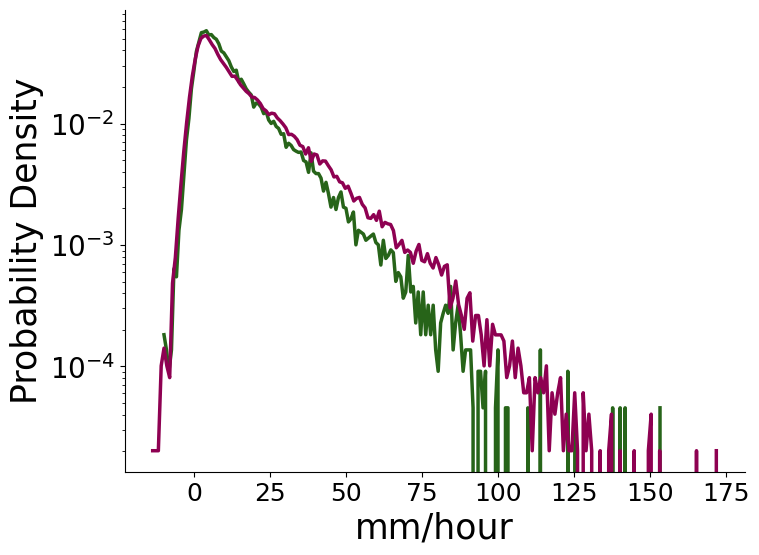

In [24]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(merged_convg_f_ctl, bins=200, density=True)
pdf_def, bin_edges_def = np.histogram(merged_convg_f_def, bins=200, density=True)

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))

plt.plot(bin_centers_ctl, pdf_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
plt.yscale('log')

#plt.xlim(-25, 50)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)
#plt.xlim(50, 200)
# Display the plot
plt.show()

## 4) Location of enhanced PR, Wa, Convg

In [25]:
# Load them back
file_pattern = "/scratch/m/m300948/test_04/pr_*.nc"
file_list = sorted(glob.glob(file_pattern))
pr_ctl_sel_mm_hour_m_6plus1_common_mask = xr.open_mfdataset(file_list, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr']

In [26]:
# Load them back
file_pattern = "/scratch/m/m300948/def_100/pr_*.nc"
file_list = sorted(glob.glob(file_pattern))
pr_def_sel_mm_hour_m_6plus1_common_mask = xr.open_mfdataset(file_list, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr']

In [15]:
def contourf(data_w, vmin_w, vmax_w, color_steps, cmap, extend, title, factor=9):
    fig = plt.figure(figsize=[8,10], facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80, -45, -16, 8])
    ax.coastlines('50m', linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                      xlocs=range(-180, 180, 20), ylocs=range(-90, 90, 10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon for data_w (original resolution)
    lats = data_w.lat
    lons = data_w.lon

    # Plot the high-resolution data_w using pcolormesh
    m = ax.pcolormesh(lons, lats, data_w, cmap=cmap, vmin=vmin_w, vmax=vmax_w, transform=ccrs.PlateCarree())

    # Reduce the resolution of data_c using the coarsen method
    #data_c_coarse = data_c.coarsen(lat=factor, lon=factor, boundary='trim').mean()

    # Plot the lower-resolution data_c using contour
    #c = ax.contour(data_c_coarse.lon, data_c_coarse.lat, data_c_coarse,
     #              colors='black', levels=np.linspace(vmin_c, vmax_c, steps), linewidth=3, labcex=3, transform=ccrs.PlateCarree())

    # Optionally label the contours
    #ax.clabel(c, inline=True, fontsize=15)

    # Plot the additional boundaries if needed
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    kw = {'levels': [-1], 'colors': ['lightgrey'], 'linestyles': ['solid']}
    plot_bd = AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)

    # Add colorbar for pcolormesh
    bounds = np.linspace(vmin_w, vmax_w, color_steps)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend, ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds, rotation=270)

    plt.title(title, fontsize=20)
    plt.show()

### 4-1) Location of enhanced Precipitation

In [27]:
pr_ctl_intense_6plus1_wet = pr_ctl_sel_mm_hour_m_6plus1_common_mask.sel(time=pr_ctl_sel_mm_hour_m_6plus1_common_mask['time'].dt.month.isin([12, 1, 2]))
pr_def_intense_6plus1_wet = pr_def_sel_mm_hour_m_6plus1_common_mask.sel(time=pr_def_sel_mm_hour_m_6plus1_common_mask['time'].dt.month.isin([12, 1, 2]))

In [28]:
pr_ctl_intense_6plus1_dry = pr_ctl_sel_mm_hour_m_6plus1_common_mask.sel(time=pr_ctl_sel_mm_hour_m_6plus1_common_mask['time'].dt.month.isin([7, 8, 9]))
pr_def_intense_6plus1_dry = pr_def_sel_mm_hour_m_6plus1_common_mask.sel(time=pr_def_sel_mm_hour_m_6plus1_common_mask['time'].dt.month.isin([7, 8, 9]))

In [29]:
count_dry_def = pr_def_intense_6plus1_dry.count(dim='time')
count_dry_ctl = pr_ctl_intense_6plus1_dry.count(dim='time')
count_wet_def = pr_def_intense_6plus1_wet.count(dim='time')
count_wet_ctl = pr_ctl_intense_6plus1_wet.count(dim='time')

In [30]:
diff_freq_pr_dry = (count_dry_def - count_dry_ctl).compute()

In [31]:
diff_freq_pr_wet = (count_wet_def - count_wet_ctl).compute()

### 4-3) Location of enhanced Convergence (Not 1 hour prior to the intense precipition, but strong convergence)

In [6]:
# Load them back
file_pattern = "/scratch/m/m300948/test_04/convg_*.nc"
file_list = sorted(glob.glob(file_pattern))
convg_ctl_m = xr.open_mfdataset(file_list, chunks={'time': 1, 'lat': -1, 'lon': -1})['__xarray_dataarray_variable__']

In [8]:
# Load them back
file_pattern = "/scratch/m/m300948/def_100/convg_*.nc"
file_list = sorted(glob.glob(file_pattern))
convg_def_m = xr.open_mfdataset(file_list, chunks={'time': 1, 'lat': -1, 'lon': -1})['__xarray_dataarray_variable__']

In [9]:
# WET
convg_ctl_wet = convg_ctl_m.sel(time=convg_ctl_m['time'].dt.month.isin([12, 1, 2]))
convg_ctl_dry = convg_ctl_m.sel(time=convg_ctl_m['time'].dt.month.isin([7, 8, 9]))

In [10]:
# DRY
convg_def_wet = convg_def_m.sel(time=convg_def_m['time'].dt.month.isin([12, 1, 2]))
convg_def_dry = convg_def_m.sel(time=convg_def_m['time'].dt.month.isin([7, 8, 9]))

In [11]:
xarray_names = ['convg_ctl_wet', 'convg_ctl_dry']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

In [12]:
# q90 for wa
new_suffix = '_q90'

xarray_names = ['convg_ctl_wet', 'convg_ctl_dry']

for name in xarray_names:
    dset_name = name + '_f' 
    xarray_data = globals()[dset_name]
    xarray_data_q99 = np.nanquantile(xarray_data, 0.9, axis=0)

    new_name = dset_name + new_suffix
    globals()[new_name] = xarray_data_q99

In [ ]:
# wet
ctl_mask_wet = (convg_ctl_wet > convg_ctl_wet_f_q90) 
def_mask_wet = (convg_def_wet > convg_ctl_wet_f_q90) 

convg_ctl_wet_above_q90 = convg_ctl_wet.where(ctl_mask_wet) 
convg_def_wet_above_q90 = convg_def_wet.where(def_mask_wet) 

In [15]:
# dry
ctl_mask_dry = (convg_ctl_dry > convg_ctl_dry_f_q90) 
def_mask_dry = (convg_def_dry > convg_ctl_dry_f_q90) 

convg_ctl_dry_above_q90 = convg_ctl_dry.where(ctl_mask_dry) 
convg_def_dry_above_q90 = convg_def_dry.where(def_mask_dry) 

In [16]:
# above q90
count_convg_wet_def = convg_def_wet_above_q90.count(dim='time')
count_convg_wet_ctl = convg_ctl_wet_above_q90.count(dim='time')
count_convg_dry_def = convg_def_dry_above_q90.count(dim='time')
count_convg_dry_ctl = convg_ctl_dry_above_q90.count(dim='time')

diff_freq_convg_wet = (count_convg_wet_def - count_convg_wet_ctl).compute()
diff_freq_convg_dry = (count_convg_dry_def - count_convg_dry_ctl).compute()

In [17]:
# above q90
mean_convg_wet_def = convg_def_wet_above_q90.mean(dim='time')
mean_convg_wet_ctl = convg_ctl_wet_above_q90.mean(dim='time')
mean_convg_dry_def = convg_def_dry_above_q90.mean(dim='time')
mean_convg_dry_ctl = convg_ctl_dry_above_q90.mean(dim='time')

diff_strength_convg_wet = (mean_convg_wet_def - mean_convg_wet_ctl).compute()
diff_strength_convg_dry = (mean_convg_dry_def - mean_convg_dry_ctl).compute()

## 5) Combined Figure

_with velocity_

In [21]:
import scipy.ndimage as ndimage

def contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9):
    fig = plt.figure(figsize=[8,10], facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80, -45, -16, 8])
    ax.coastlines('50m', linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                      xlocs=range(-180, 180, 20), ylocs=range(-90, 90, 10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon for data_w (original resolution)
    lats = data_w.lat
    lons = data_w.lon

    # Plot the high-resolution data_w using pcolormesh
    m = ax.pcolormesh(lons, lats, data_w, cmap=cmap, vmin=vmin_w, vmax=vmax_w, transform=ccrs.PlateCarree())

    # Reduce the resolution of data_c using the coarsen method
    data_c1_coarse = data_c.coarsen(lat=factor, lon=factor, boundary='trim').mean()
    data_c2_coarse = data_pr #.coarsen(lat=factor, lon=factor, boundary='trim').mean()

    # Smooth the data_pr to reduce spotty noise
    #data_pr_smoothed = ndimage.gaussian_filter(data_c2_coarse, sigma=1)

    # Plot the lower-resolution data_c using contour
    c1 = ax.contour(data_c1_coarse.lon, data_c1_coarse.lat, data_c1_coarse,
                   colors='black', levels=np.linspace(vmin_c, vmax_c, steps), linewidth=3, labcex=3, transform=ccrs.PlateCarree())
    
    # Plot the smoothed data_pr using contourf with hatching for values above 1
    c2 = ax.contourf(data_c2_coarse.lon, data_c2_coarse.lat, data_c2_coarse,
                     levels=np.linspace(vmin_pr, vmax_pr, steps2), hatches=['/'], #, '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'], 
                     colors='none', transform=ccrs.PlateCarree())

    # Overlay contour lines to highlight boundaries
    ax.contour(data_c2_coarse.lon, data_c2_coarse.lat, data_c2_coarse,
               levels=np.linspace(vmin_pr, vmax_pr, steps2), colors='red', linewidths=2, transform=ccrs.PlateCarree())

    # Optionally label the contours
    ax.clabel(c1, inline=True, fontsize=15)

    # Plot the additional boundaries if needed
    kw = {'levels': [-1], 'colors': ['lightgrey'], 'linestyles': ['solid']}
    plot_bd = AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)

    # Add colorbar for pcolormesh
    bounds = np.linspace(vmin_w, vmax_w, color_steps)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend, ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds, rotation=270)

    plt.title(title, fontsize=20)
    plt.show()

_without velocity_

In [47]:
import scipy.ndimage as ndimage
# Convg - Black contour, PR - Red contour, PR - Hatched
def contourf_wo_w(data_c, vmin_c, vmax_c, steps, data_pr, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9):
    fig = plt.figure(figsize=[8,10], facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80, -45, -16, 8])
    ax.coastlines('50m', linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                      xlocs=range(-180, 180, 20), ylocs=range(-90, 90, 10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon for data_w (original resolution)
    lats = data_pr.lat
    lons = data_pr.lon

    # Plot the high-resolution pr
    m = ax.pcolormesh(lons, lats, data_pr, cmap=cmap, vmin=vmin_pr, vmax=vmax_pr, transform=ccrs.PlateCarree())
    # Add colorbar for pcolormesh
    bounds = np.linspace(vmin_pr, vmax_pr, steps2)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend, ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds, rotation=270)

    # Reduce the resolution of data_c using the coarsen method
    data_c1_coarse = data_c.coarsen(lat=factor, lon=factor, boundary='trim').mean()
    # Plot the lower-resolution data_c using contour
    c1 = ax.contour(data_c1_coarse.lon, data_c1_coarse.lat, data_c1_coarse,
                   colors='Blue', levels=np.linspace(vmin_c, vmax_c, steps), linewidths=3, labcex=3, transform=ccrs.PlateCarree())
    
    # Plot the smoothed data_pr using contourf with hatching for values above 1
    #c2 = ax.contourf(data_c2_coarse.lon, data_c2_coarse.lat, data_c2_coarse,
    #                 levels=np.linspace(vmin_pr, vmax_pr, steps2), hatches=['/'], #, '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'], 
    #                 colors='none', transform=ccrs.PlateCarree())

    # Optionally label the contours
    #ax.clabel(c1, inline=True, fontsize=25)

    # Plot the additional boundaries if needed
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    kw = {'levels': [-1], 'colors': ['lightgrey'], 'linestyles': ['solid']}
    plot_bd = AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)
    

    # Add colorbar for pcolormesh
    plt.title(title, fontsize=20)
    plt.show()

In [ ]:
factor = 9
diff_convg_dry_coarse = diff_freq_convg_dry.coarsen(lat=factor, lon=factor, boundary='trim').mean()
diff_convg_wet_coarse = diff_freq_convg_wet.coarsen(lat=factor, lon=factor, boundary='trim').mean()

In [ ]:
factor = 3
diff_convg_strength_dry_coarse = diff_strength_convg_dry.coarsen(lat=factor, lon=factor, boundary='trim').mean()
diff_convg_strength_wet_coarse = diff_strength_convg_wet.coarsen(lat=factor, lon=factor, boundary='trim').mean()

In [52]:
factor = 2
diff_pr_freq_dry_coarse = diff_freq_pr_dry.coarsen(lat=factor, lon=factor, boundary='trim').sum()
diff_pr_freq_wet_coarse = diff_freq_pr_wet.coarsen(lat=factor, lon=factor, boundary='trim').sum()
data_pr_smoothed = ndimage.gaussian_filter(diff_pr_dry_coarse, sigma=1)

In [ ]:
factor = 3
diff_pr_dry_strength_coarse = diff_strength_pr_dry.coarsen(lat=factor, lon=factor, boundary='trim').mean()
diff_pr_wet_strength_coarse = diff_strength_pr_wet.coarsen(lat=factor, lon=factor, boundary='trim').mean()
data_pr_smoothed = ndimage.gaussian_filter(diff_pr_dry_coarse, sigma=1)

In [ ]:
#contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9)
contourf(diff_freq_wa_dry, diff_freq_convg_dry, diff_pr_dry_coarse, 
         -50, 50, 11, 
         0, 100, 3, 
         5, 10, 2, 'PiYG_r', 'both', '')

In [31]:
diff_strength_dry_2022 = diff_strength_dry
diff_pr_dry_coarse_2022 = diff_pr_dry_coarse

In [32]:
diff_strength_dry_2022.to_netcdf('/scratch/m/m300948/def_100/' + 'diff_strength_dry_2022.nc')
diff_pr_dry_coarse_2022.to_netcdf('/scratch/m/m300948/def_100/' + 'diff_pr_dry_coarse_2022.nc')

_load all years_

In [ ]:
diff_strength_dry_all = xr.open_mfdataset('/scratch/m/m300948/def_100/diff_strength_dry*.nc', concat_dim='time', combine='nested')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [37]:
diff_pr_dry_coarse_all = xr.open_mfdataset('/scratch/m/m300948/def_100/diff_pr_dry_coarse*.nc', concat_dim='time', combine='nested')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/cartopy/mpl/gridliner.py:475: UserWarning: The .ylabels_left attribute is deprecated. Please use .left_labels to toggle visibility instead.
  warnings.warn('The .ylabels_left attribute is deprecated. Please '
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: The following kwargs were not used by contour: 'labcex'
  result = super().contour(*args, **kwargs)


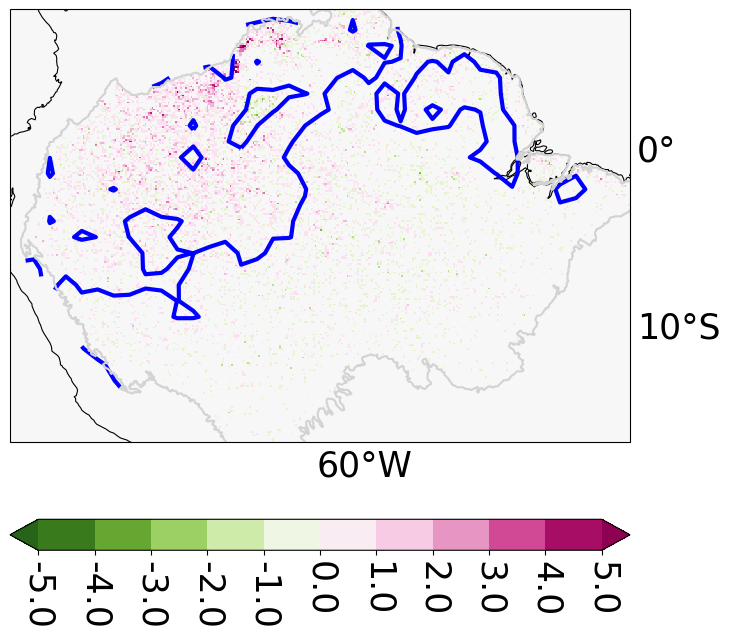

In [55]:
#contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9)
contourf_wo_w(diff_strength_convg_dry, 0, 1, 1, 
              diff_freq_pr_dry, -5, 5, 11, 'PiYG_r', 'both', '')

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/cartopy/mpl/gridliner.py:475: UserWarning: The .ylabels_left attribute is deprecated. Please use .left_labels to toggle visibility instead.
  warnings.warn('The .ylabels_left attribute is deprecated. Please '
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: The following kwargs were not used by contour: 'labcex'
  result = super().contour(*args, **kwargs)


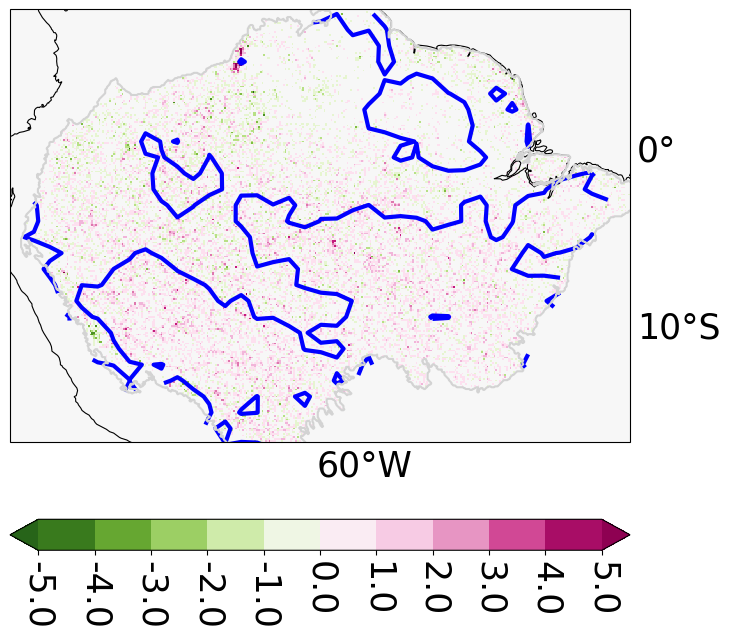

In [56]:
#contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9)
contourf_wo_w(diff_strength_convg_wet, 0, 1, 1, 
              diff_freq_pr_wet, -5, 5, 11, 'PiYG_r', 'both', '')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:475: UserWarning: The .ylabels_left attribute is deprecated. Please use .left_labels to toggle visibility instead.
  warnings.warn('The .ylabels_left attribute is deprecated. Please '
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: The following kwargs were not used by contour: 'labcex'
  result = super().contour(*args, **kwargs)


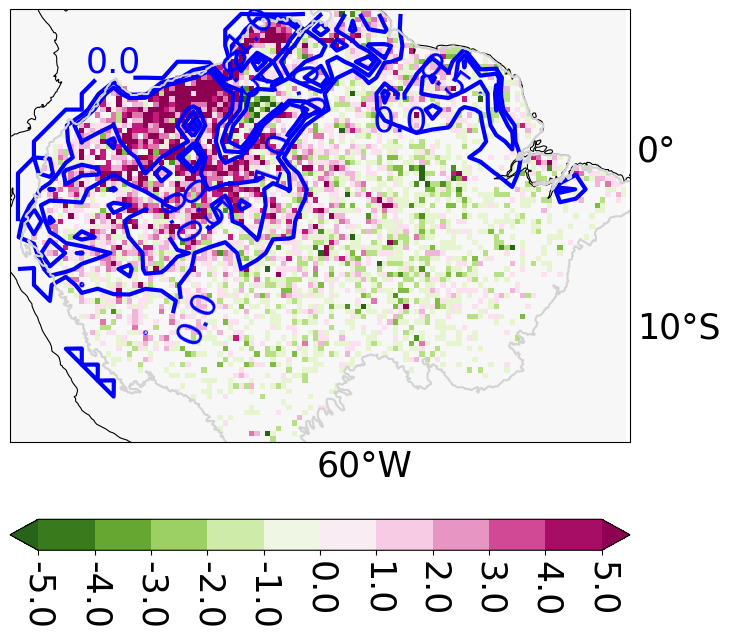

In [70]:
#contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9)
contourf_wo_w(diff_strength_dry_all.__xarray_dataarray_variable__.sum(dim='time'), 0, 1, 3, 
              diff_pr_dry_coarse_all.pr.sum(dim='time'), -5, 5, 11, 'PiYG_r', 'both', '')

_WET_

In [37]:
diff_strength_wet_2022 = diff_strength_wet
diff_pr_wet_coarse_2022 = diff_pr_wet_coarse

In [ ]:
diff_strength_wet_2022.to_netcdf('/scratch/m/m300948/def_100/' + 'diff_strength_wet_2022.nc')
diff_pr_wet_coarse_2022.to_netcdf('/scratch/m/m300948/def_100/' + 'diff_pr_wet_coarse_2022.nc')

_load all years_

In [55]:
diff_strength_wet_all = xr.open_mfdataset('/scratch/m/m300948/def_100/diff_strength_wet*.nc', concat_dim='time', combine='nested')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [56]:
diff_pr_wet_coarse_all = xr.open_mfdataset('/scratch/m/m300948/def_100/diff_pr_wet_coarse*.nc', concat_dim='time', combine='nested')

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:475: UserWarning: The .ylabels_left attribute is deprecated. Please use .left_labels to toggle visibility instead.
  warnings.warn('The .ylabels_left attribute is deprecated. Please '
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: The following kwargs were not used by contour: 'labcex'
  result = super().contour(*args, **kwargs)


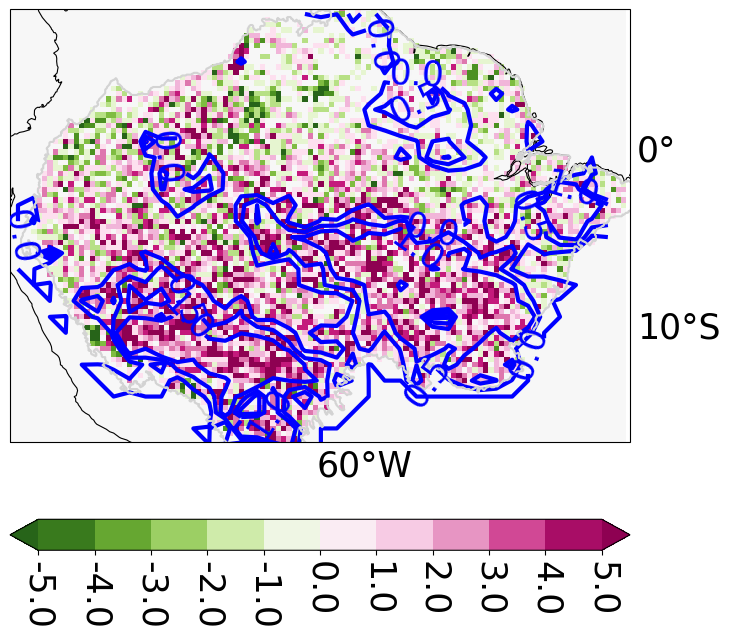

In [71]:
#contourf(data_w, data_c, data_pr, vmin_w, vmax_w, color_steps, vmin_c, vmax_c, steps, vmin_pr, vmax_pr, steps2, cmap, extend, title, factor=9)
contourf_wo_w(diff_strength_wet_all.__xarray_dataarray_variable__.sum(dim='time'), 0, 1, 3, 
              diff_pr_wet_coarse_all.pr.sum(dim='time'), -5, 5, 11, 'PiYG_r', 'both', '')